# Notebook 04: Model Training

## Objective
Train an **LGBMRanker** (LambdaMART) model on the Expedia Hotel Search dataset with:
- Multi-objective **composite labels** that combine clicks, bookings, and revenue
- **IPS sample weights** to correct for position bias
- **Early stopping** on validation NDCG to prevent overfitting

## Why LambdaMART?

LambdaMART is the industry-standard algorithm for Learning-to-Rank. It combines:
1. **Lambda gradients** -- derived from NDCG, so each gradient step directly optimises the ranking metric (not a surrogate like MSE or cross-entropy).
2. **MART (Multiple Additive Regression Trees)** -- gradient-boosted decision trees that handle non-linear feature interactions naturally and are robust to feature scale.

LightGBM's `lambdarank` objective implements LambdaMART with histogram-based splitting for fast training on large datasets.

### The Group Parameter
Unlike standard supervised learning, LTR models need to know which items belong to the same query. The `group` array tells LGBMRanker: `group[i]` = number of items in query *i*. The model computes pairwise lambda gradients *within* each query -- items from different queries never form pairs.

In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Data Preparation

Load the data, preprocess, split, and build the feature matrix.

In [2]:
from hotel_ranker.data.acquisition import find_csv
from hotel_ranker.data.preprocessing import preprocess
from hotel_ranker.data.splitting import query_level_split, get_groups
from hotel_ranker.features.feature_pipeline import build_features

# Load and preprocess
csv_path = find_csv()
df = preprocess(csv_path)

# Query-level split
train_df, val_df, test_df = query_level_split(df)

print(f"Train: {train_df.shape[0]:,} rows ({train_df['srch_id'].nunique():,} queries)")
print(f"Val:   {val_df.shape[0]:,} rows ({val_df['srch_id'].nunique():,} queries)")
print(f"Test:  {test_df.shape[0]:,} rows ({test_df['srch_id'].nunique():,} queries)")

Train: 6,941,198 rows (279,540 queries)
Val:   1,487,064 rows (59,901 queries)
Test:  1,489,268 rows (59,903 queries)


In [3]:
# Build feature matrices (without embeddings for speed)
X_train = build_features(train_df, train_df, use_embeddings=False)
X_val = build_features(val_df, train_df, use_embeddings=False)

print(f"Feature matrix: {X_train.shape[1]} features")
print(f"Features: {list(X_train.columns)}")

Feature matrix: 40 features
Features: ['prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'promotion_flag', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'price_per_night', 'total_guests', 'star_review_ratio', 'price_vs_visitor_hist', 'price_log', 'price_rank_in_query', 'price_diff_from_query_mean', 'price_ratio_to_query_median', 'price_zscore_in_query', 'star_diff_from_query_mean', 'star_match_visitor_pref', 'location_score_composite', 'competitor_rate_advantage', 'competitor_rate_disadvantage', 'competitor_rate_mean', 'competitor_inv_advantage', 'prop_click_rate', 'prop_booking_rate', 'prop_avg_position', 'prop_impression_count', 'dest_avg_price', 'dest_avg_star', 'dest_booking_rate', 'price_vs_dest_avg']


## 2. Label Engineering

Standard ranking datasets have binary labels (clicked / not clicked). This is limiting because:
- A click on a cheap hotel and a booking on an expensive hotel are not equally valuable.
- Bookings are a much stronger relevance signal than clicks.

### Multi-Objective Composite Label
We create a composite relevance score:

$$y = w_1 \cdot \text{click\_bool} + w_2 \cdot \text{booking\_bool} \cdot \log(1 + \text{price\_usd})$$

- $w_1 = 1.0$ -- base reward for a click
- $w_2 = 5.0$ -- multiplier for bookings (bookings are 5x more important)
- $\log(1 + \text{price})$ -- scales booking value by revenue, using log to prevent expensive hotels from completely dominating

### Discretization into Relevance Grades
LambdaRank / NDCG work with ordinal relevance grades (e.g., 0-4). We:
1. Min-max normalise the composite score within each query to [0, 1]
2. Map to discrete grades via `floor(normalised * max_grade)`
3. Ensure zero-score items always get grade 0

This ensures: Grade 0 = no interaction, Grade 4 = highest-value item in the query.

In [4]:
from hotel_ranker.training.label_engineering import compute_composite_label, discretize_labels
from hotel_ranker.config import W_CLICK, W_BOOK, MAX_RELEVANCE_GRADE

print(f"Label weights: W_CLICK={W_CLICK}, W_BOOK={W_BOOK}")
print(f"Max relevance grade: {MAX_RELEVANCE_GRADE}")

# Step 1: Compute raw composite scores
raw_scores_train = compute_composite_label(train_df)
raw_scores_val = compute_composite_label(val_df)

print(f"\nRaw composite scores (train):")
print(f"  Min:    {raw_scores_train.min():.4f}")
print(f"  Median: {raw_scores_train.median():.4f}")
print(f"  Mean:   {raw_scores_train.mean():.4f}")
print(f"  Max:    {raw_scores_train.max():.4f}")
print(f"  Non-zero: {(raw_scores_train > 0).sum():,} ({(raw_scores_train > 0).mean()*100:.1f}%)")

Label weights: W_CLICK=1.0, W_BOOK=5.0
Max relevance grade: 4

Raw composite scores (train):
  Min:    0.0000
  Median: 0.0000
  Mean:   0.7089
  Max:    76.7256
  Non-zero: 310,663 (4.5%)


In [5]:
# Step 2: Discretize into relevance grades
y_train = discretize_labels(raw_scores_train, train_df['srch_id'], max_grade=MAX_RELEVANCE_GRADE)
y_val = discretize_labels(raw_scores_val, val_df['srch_id'], max_grade=MAX_RELEVANCE_GRADE)

print(f"Label distribution (train):")
for grade in range(MAX_RELEVANCE_GRADE + 1):
    count = (y_train == grade).sum()
    pct = count / len(y_train) * 100
    print(f"  Grade {grade}: {count:>8,} ({pct:5.1f}%)")

Label distribution (train):
  Grade 0: 6,650,163 ( 95.8%)
  Grade 1:        0 (  0.0%)
  Grade 2:        2 (  0.0%)
  Grade 3:        0 (  0.0%)
  Grade 4:  291,033 (  4.2%)


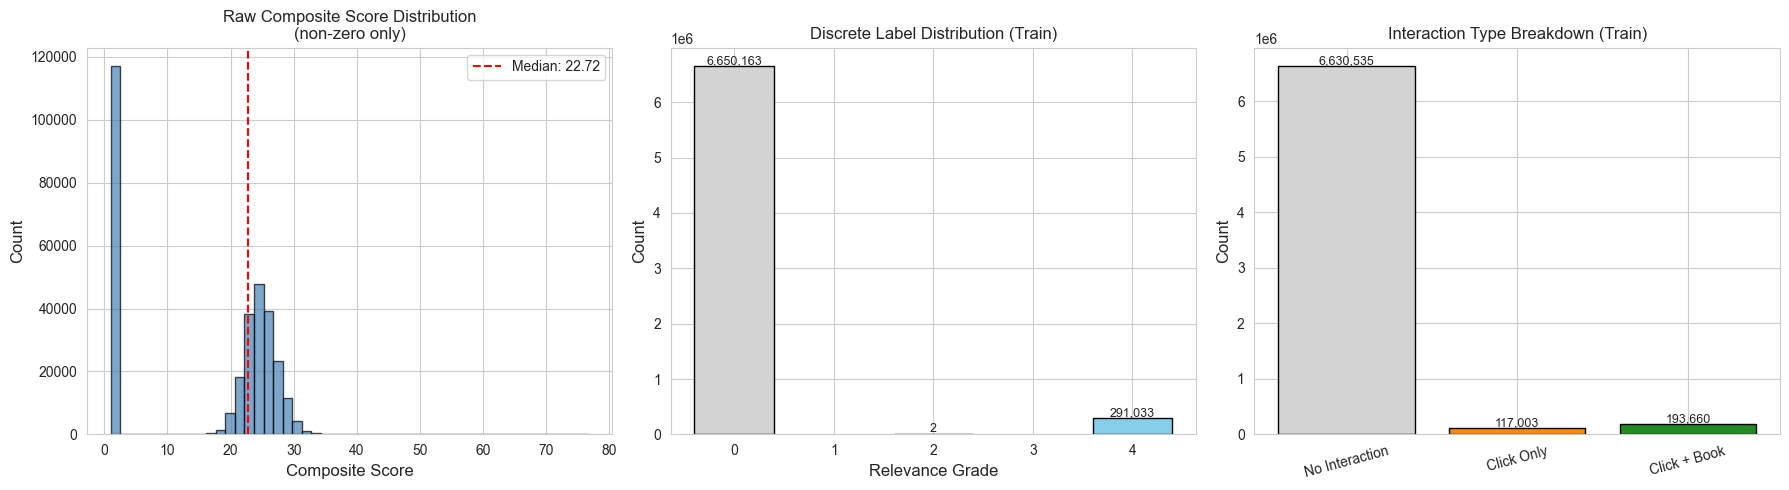

In [6]:
# Visualize label distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Raw composite score distribution
ax1 = axes[0]
non_zero_scores = raw_scores_train[raw_scores_train > 0]
ax1.hist(non_zero_scores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_xlabel('Composite Score', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Raw Composite Score Distribution\n(non-zero only)', fontsize=12)
ax1.axvline(non_zero_scores.median(), color='red', linestyle='--',
            label=f'Median: {non_zero_scores.median():.2f}')
ax1.legend()

# Middle: Discrete grade distribution
ax2 = axes[1]
grades, counts = np.unique(y_train, return_counts=True)
colors = ['lightgray', 'lightblue', 'skyblue', 'steelblue', 'darkblue']
ax2.bar(grades, counts, color=colors[:len(grades)], edgecolor='black')
ax2.set_xlabel('Relevance Grade', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Discrete Label Distribution (Train)', fontsize=12)
for g, c in zip(grades, counts):
    ax2.text(g, c + len(y_train)*0.005, f'{c:,}', ha='center', fontsize=9)

# Right: Score breakdown by interaction type
ax3 = axes[2]
categories = ['No Interaction', 'Click Only', 'Click + Book']
no_interaction = ((train_df['click_bool'] == 0) & (train_df['booking_bool'] == 0)).sum()
click_only = ((train_df['click_bool'] == 1) & (train_df['booking_bool'] == 0)).sum()
click_book = ((train_df['click_bool'] == 1) & (train_df['booking_bool'] == 1)).sum()
# Also count book without click (edge case)
book_no_click = ((train_df['click_bool'] == 0) & (train_df['booking_bool'] == 1)).sum()
if book_no_click > 0:
    categories.append('Book (no click)')
    vals = [no_interaction, click_only, click_book, book_no_click]
else:
    vals = [no_interaction, click_only, click_book]
bar_colors = ['lightgray', 'darkorange', 'forestgreen', 'mediumpurple'][:len(vals)]
ax3.bar(categories, vals, color=bar_colors, edgecolor='black')
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('Interaction Type Breakdown (Train)', fontsize=12)
for i, v in enumerate(vals):
    ax3.text(i, v + len(y_train)*0.005, f'{v:,}', ha='center', fontsize=9)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15)

plt.tight_layout()
plt.show()

## 3. Group Arrays

LGBMRanker needs a `group` array that specifies how many items belong to each query. The data must be sorted by `srch_id` so items from the same query are contiguous.

In [7]:
# Sort by search ID and compute groups
train_sorted = train_df.sort_values('srch_id').reset_index(drop=True)
val_sorted = val_df.sort_values('srch_id').reset_index(drop=True)

# Re-align features and labels with sorted order
X_train_sorted = X_train.loc[train_sorted.index] if X_train.index.equals(train_df.index) else build_features(train_sorted, train_sorted, use_embeddings=False)
X_val_sorted = X_val.loc[val_sorted.index] if X_val.index.equals(val_df.index) else build_features(val_sorted, train_sorted, use_embeddings=False)

# Recompute labels for sorted data
y_train_sorted = discretize_labels(
    compute_composite_label(train_sorted),
    train_sorted['srch_id'],
    max_grade=MAX_RELEVANCE_GRADE
)
y_val_sorted = discretize_labels(
    compute_composite_label(val_sorted),
    val_sorted['srch_id'],
    max_grade=MAX_RELEVANCE_GRADE
)

# Compute group arrays
groups_train = get_groups(train_sorted)
groups_val = get_groups(val_sorted)

print(f"Training groups: {len(groups_train):,} queries")
print(f"  Items per query: min={groups_train.min()}, mean={groups_train.mean():.1f}, max={groups_train.max()}")
print(f"  Total items: {groups_train.sum():,}")
print(f"\nValidation groups: {len(groups_val):,} queries")
print(f"  Items per query: min={groups_val.min()}, mean={groups_val.mean():.1f}, max={groups_val.max()}")

Training groups: 279,540 queries
  Items per query: min=5, mean=24.8, max=38
  Total items: 6,941,198

Validation groups: 59,901 queries
  Items per query: min=5, mean=24.8, max=38


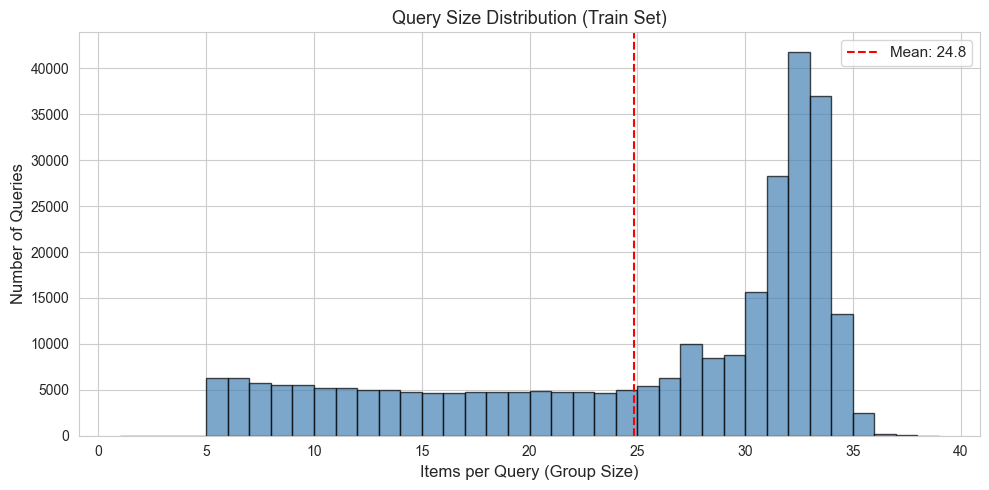

In [8]:
# Visualize query size distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(groups_train, bins=range(1, groups_train.max() + 2), edgecolor='black',
        alpha=0.7, color='steelblue')
ax.set_xlabel('Items per Query (Group Size)', fontsize=12)
ax.set_ylabel('Number of Queries', fontsize=12)
ax.set_title('Query Size Distribution (Train Set)', fontsize=13)
ax.axvline(groups_train.mean(), color='red', linestyle='--',
           label=f'Mean: {groups_train.mean():.1f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. IPS Sample Weights

We compute Inverse Propensity Scoring weights to correct for position bias during training. Items clicked at lower positions receive higher weights because the user had to actively scroll to find them, suggesting stronger relevance intent.

In [9]:
from hotel_ranker.bias.propensity import estimate_propensity, compute_ips_weights

# Estimate propensity from the full dataset (random items are spread across all splits)
propensity_result = estimate_propensity(df)

# Compute IPS weights for the training set
ips_weights = compute_ips_weights(train_sorted, propensity_result)

print(f"IPS weight statistics:")
print(f"  Min:    {ips_weights.min():.4f}")
print(f"  Median: {np.median(ips_weights):.4f}")
print(f"  Mean:   {ips_weights.mean():.4f}")
print(f"  Max:    {ips_weights.max():.4f}")

IPS weight statistics:
  Min:    1.0000
  Median: 1.0000
  Mean:   1.0000
  Max:    1.0000


## 5. LGBMRanker Configuration

Let's examine the model hyperparameters before training.

In [10]:
from hotel_ranker.config import LGBM_PARAMS, EARLY_STOPPING_ROUNDS

print("LGBMRanker Hyperparameters:")
print("=" * 50)
for key, value in LGBM_PARAMS.items():
    explanation = {
        'objective': 'LambdaRank (pairwise ranking loss derived from NDCG)',
        'metric': 'Evaluation metric (NDCG)',
        'eval_at': 'NDCG cutoff positions for evaluation',
        'n_estimators': 'Maximum number of boosting rounds',
        'num_leaves': 'Max leaves per tree (controls model complexity)',
        'learning_rate': 'Step size shrinkage (lower = more conservative)',
        'min_child_samples': 'Minimum samples in a leaf (regularisation)',
        'subsample': 'Row subsampling ratio (stochastic gradient boosting)',
        'colsample_bytree': 'Column subsampling ratio per tree',
        'reg_alpha': 'L1 regularisation on leaf weights',
        'reg_lambda': 'L2 regularisation on leaf weights',
        'random_state': 'Random seed for reproducibility',
        'n_jobs': 'Number of parallel threads (-1 = all cores)',
        'verbose': 'Logging verbosity (-1 = silent)',
    }
    desc = explanation.get(key, '')
    print(f"  {key:25s} = {str(value):10s} {desc}")

print(f"\nEarly stopping rounds: {EARLY_STOPPING_ROUNDS}")
print("  (Stop if validation NDCG doesn't improve for this many rounds)")

LGBMRanker Hyperparameters:
  objective                 = lambdarank LambdaRank (pairwise ranking loss derived from NDCG)
  metric                    = ndcg       Evaluation metric (NDCG)
  eval_at                   = [5, 10]    NDCG cutoff positions for evaluation
  n_estimators              = 500        Maximum number of boosting rounds
  num_leaves                = 63         Max leaves per tree (controls model complexity)
  learning_rate             = 0.05       Step size shrinkage (lower = more conservative)
  min_child_samples         = 50         Minimum samples in a leaf (regularisation)
  subsample                 = 0.8        Row subsampling ratio (stochastic gradient boosting)
  colsample_bytree          = 0.8        Column subsampling ratio per tree
  reg_alpha                 = 0.1        L1 regularisation on leaf weights
  reg_lambda                = 1.0        L2 regularisation on leaf weights
  random_state              = 42         Random seed for reproducibility
  n_j

## 6. Training the LGBMRanker

Now we train the model with:
- Discrete relevance labels (grades 0-4)
- Query group information
- IPS sample weights for position debiasing
- Early stopping on validation NDCG@5

In [11]:
from hotel_ranker.training.trainer import train_ranker

# Train the ranker
model = train_ranker(
    X_train=X_train_sorted,
    y_train=y_train_sorted,
    groups_train=groups_train,
    X_val=X_val_sorted,
    y_val=y_val_sorted,
    groups_val=groups_val,
    sample_weight=ips_weights,
)

print(f"\nTraining complete!")
print(f"Best iteration: {model.best_iteration_}")
print(f"Best NDCG@5 (validation): {model.best_score_['valid_0']['ndcg@5']:.4f}")
print(f"Best NDCG@10 (validation): {model.best_score_['valid_0']['ndcg@10']:.4f}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's ndcg@5: 0.369603	valid_0's ndcg@10: 0.434546
[100]	valid_0's ndcg@5: 0.377457	valid_0's ndcg@10: 0.442065
[150]	valid_0's ndcg@5: 0.382043	valid_0's ndcg@10: 0.446563
[200]	valid_0's ndcg@5: 0.384053	valid_0's ndcg@10: 0.448614
[250]	valid_0's ndcg@5: 0.385372	valid_0's ndcg@10: 0.449654
[300]	valid_0's ndcg@5: 0.386185	valid_0's ndcg@10: 0.450403
[350]	valid_0's ndcg@5: 0.386803	valid_0's ndcg@10: 0.450926
Early stopping, best iteration is:
[343]	valid_0's ndcg@5: 0.386829	valid_0's ndcg@10: 0.451069

Training complete!
Best iteration: 343
Best NDCG@5 (validation): 0.3868
Best NDCG@10 (validation): 0.4511


## 7. Training Curves

Let's visualize how the model's NDCG improved over boosting iterations. We look for:
- Steady improvement on both train and validation sets
- Early stopping before overfitting (validation score plateaus or degrades)

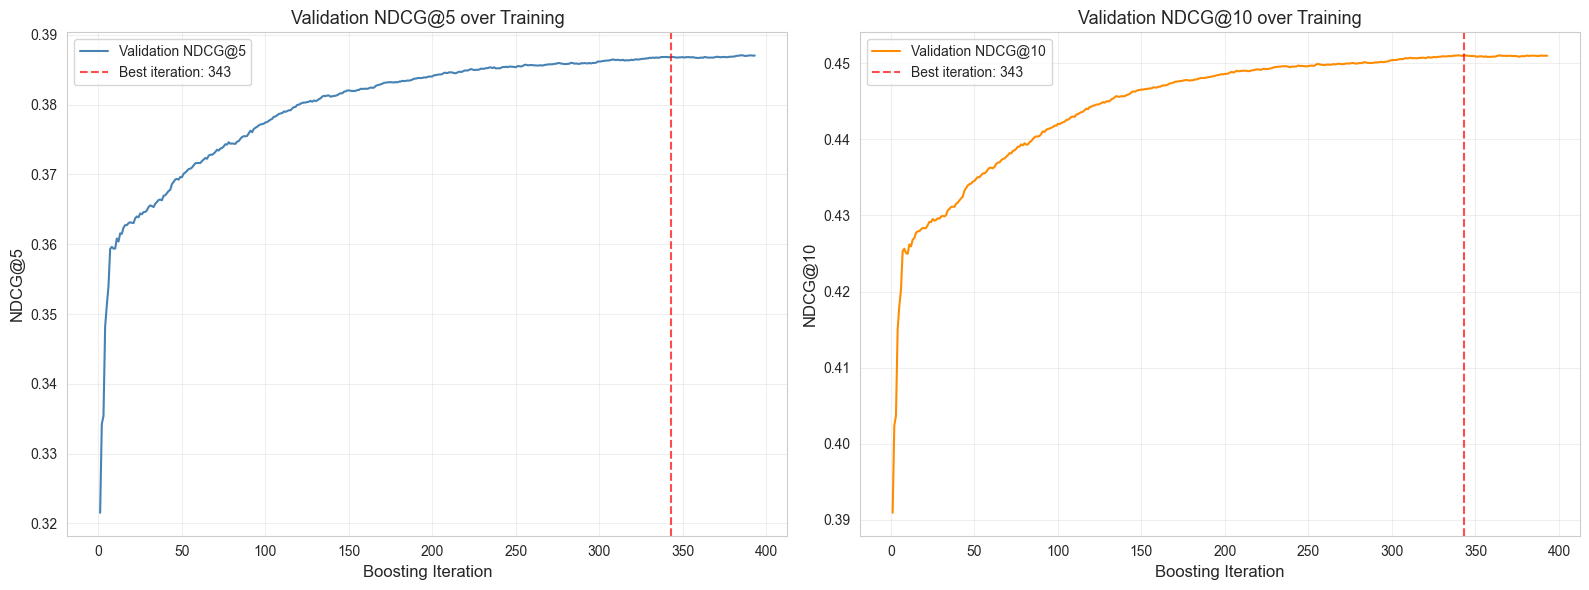

In [12]:
# Extract training history
results = model.evals_result_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NDCG@5 over iterations
if 'valid_0' in results and 'ndcg@5' in results['valid_0']:
    ndcg5_vals = results['valid_0']['ndcg@5']
    iterations = range(1, len(ndcg5_vals) + 1)
    
    ax1 = axes[0]
    ax1.plot(iterations, ndcg5_vals, color='steelblue', linewidth=1.5, label='Validation NDCG@5')
    ax1.axvline(model.best_iteration_, color='red', linestyle='--', alpha=0.7,
                label=f'Best iteration: {model.best_iteration_}')
    ax1.set_xlabel('Boosting Iteration', fontsize=12)
    ax1.set_ylabel('NDCG@5', fontsize=12)
    ax1.set_title('Validation NDCG@5 over Training', fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

# NDCG@10 over iterations
if 'valid_0' in results and 'ndcg@10' in results['valid_0']:
    ndcg10_vals = results['valid_0']['ndcg@10']
    
    ax2 = axes[1]
    ax2.plot(range(1, len(ndcg10_vals) + 1), ndcg10_vals, color='darkorange',
             linewidth=1.5, label='Validation NDCG@10')
    ax2.axvline(model.best_iteration_, color='red', linestyle='--', alpha=0.7,
                label=f'Best iteration: {model.best_iteration_}')
    ax2.set_xlabel('Boosting Iteration', fontsize=12)
    ax2.set_ylabel('NDCG@10', fontsize=12)
    ax2.set_title('Validation NDCG@10 over Training', fontsize=13)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

LightGBM provides feature importance based on the number of times each feature is used in split decisions across all trees. Features used more frequently are more important for the ranking.

In [13]:
from hotel_ranker.training.trainer import get_feature_importance

# Get feature importance
fi_df = get_feature_importance(model, list(X_train_sorted.columns))

print("Top 20 Features by Importance:")
print("=" * 50)
for i, row in fi_df.head(20).iterrows():
    bar = '#' * int(row['importance'] / fi_df['importance'].max() * 40)
    print(f"  {row['feature']:35s} {row['importance']:6.0f}  {bar}")

Top 20 Features by Importance:
  prop_impression_count                 1949  ########################################
  prop_log_historical_price             1868  ######################################
  prop_location_score2                  1651  #################################
  prop_click_rate                       1467  ##############################
  price_usd                             1459  #############################
  star_diff_from_query_mean             1427  #############################
  price_zscore_in_query                 1169  #######################
  price_ratio_to_query_median            999  ####################
  prop_booking_rate                      980  ####################
  price_per_night                        931  ###################
  prop_avg_position                      917  ##################
  prop_location_score1                   741  ###############
  prop_review_score                      726  ##############
  price_rank_in_query         

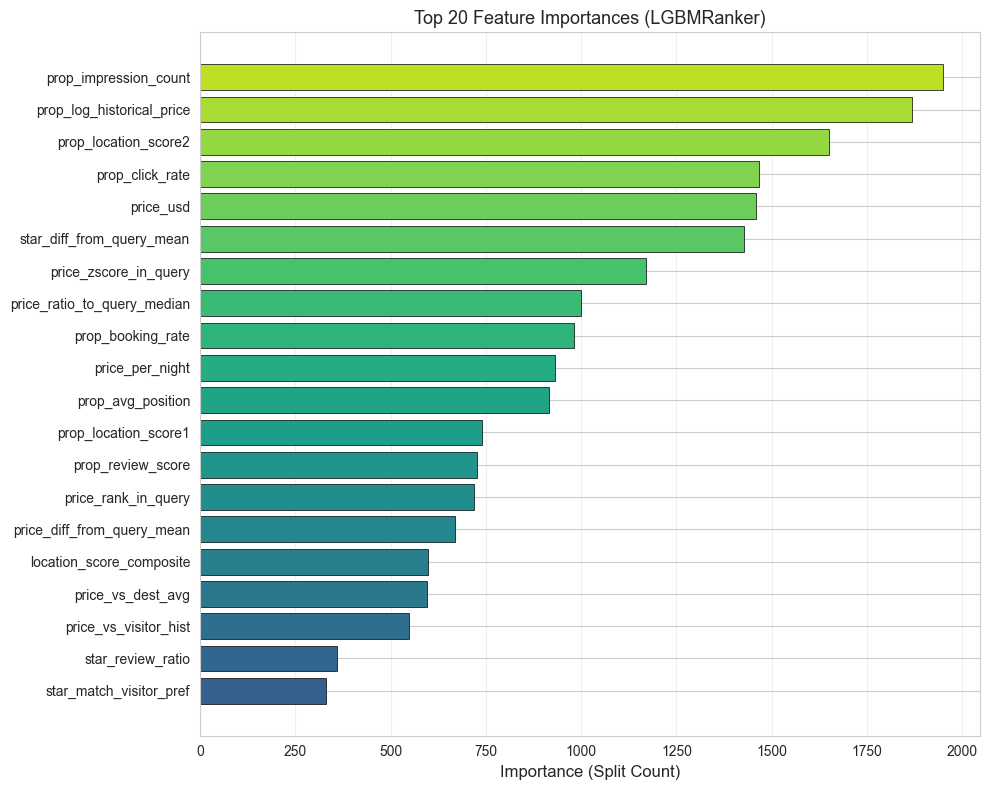

In [14]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 8))

top_n = min(20, len(fi_df))
top_fi = fi_df.head(top_n).iloc[::-1]  # reverse for horizontal bar

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(top_fi['feature'], top_fi['importance'], color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importance (Split Count)', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importances (LGBMRanker)', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Feature Importance by Category

Let's see which feature *categories* contribute the most to the model's decisions.

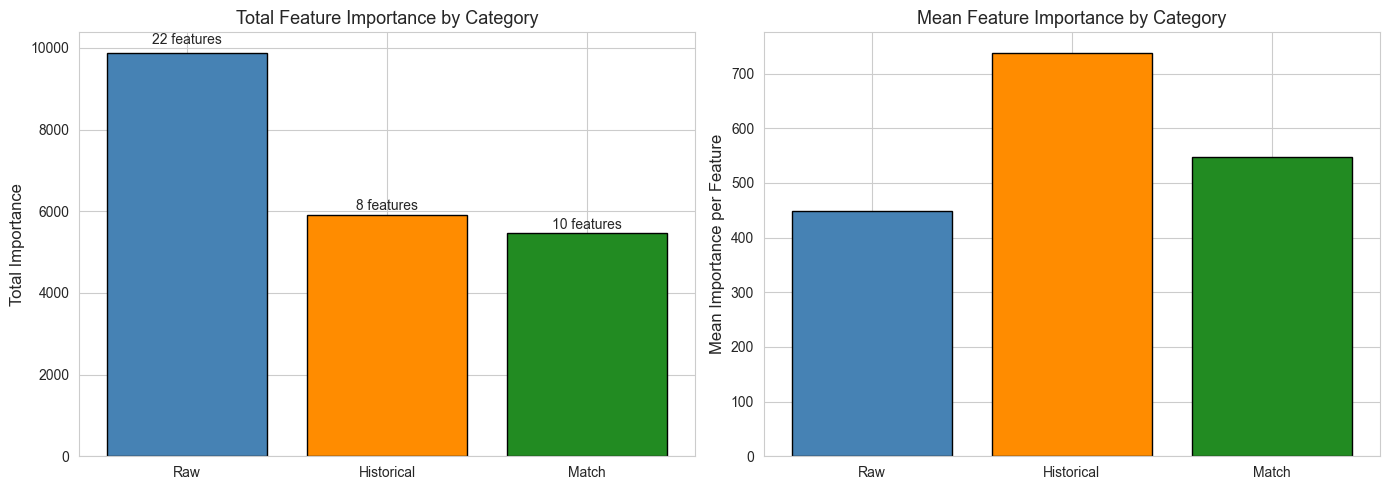

            Total Importance  Num Features  Mean Importance
category                                                   
Raw                     9889            22         449.5000
Historical              5909             8         738.6250
Match                   5468            10         546.8000


In [15]:
# Categorize features
def categorize_feature(name):
    hist_keywords = ['click_rate', 'booking_rate', 'impression', 'avg_position',
                     'dest_avg', 'dest_booking', 'price_vs_dest']
    if any(kw in name for kw in hist_keywords):
        return 'Historical'
    match_keywords = ['query_mean', 'query_median', 'zscore', 'match', 'composite',
                      'competitor', 'diff_from', 'ratio_to']
    if any(kw in name for kw in match_keywords):
        return 'Match'
    if name.startswith('emb_') or 'similarity' in name:
        return 'Embedding'
    return 'Raw'

fi_df['category'] = fi_df['feature'].apply(categorize_feature)

category_importance = fi_df.groupby('category')['importance'].agg(['sum', 'count', 'mean'])
category_importance.columns = ['Total Importance', 'Num Features', 'Mean Importance']
category_importance = category_importance.sort_values('Total Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Total importance by category
ax1 = axes[0]
colors_cat = ['steelblue', 'darkorange', 'forestgreen', 'mediumpurple']
ax1.bar(category_importance.index, category_importance['Total Importance'],
        color=colors_cat[:len(category_importance)], edgecolor='black')
ax1.set_ylabel('Total Importance', fontsize=12)
ax1.set_title('Total Feature Importance by Category', fontsize=13)
for i, (idx, row) in enumerate(category_importance.iterrows()):
    ax1.text(i, row['Total Importance'] * 1.02,
             f"{int(row['Num Features'])} features", ha='center', fontsize=10)

# Right: Mean importance by category
ax2 = axes[1]
ax2.bar(category_importance.index, category_importance['Mean Importance'],
        color=colors_cat[:len(category_importance)], edgecolor='black')
ax2.set_ylabel('Mean Importance per Feature', fontsize=12)
ax2.set_title('Mean Feature Importance by Category', fontsize=13)

plt.tight_layout()
plt.show()

print(category_importance.to_string())

## 9. Save the Model

Save the trained model for later use in evaluation (Notebook 05) and inference.

In [16]:
from hotel_ranker.training.trainer import save_model

model_path = save_model(model)
print(f"Model saved to: {model_path}")
print(f"Model file size: {model_path.stat().st_size / 1024:.1f} KB")

Model saved to: D:\Industry Projects\LTR system\models\lgbm_ranker.pkl
Model file size: 2429.1 KB


## 10. Quick Validation Check

Before moving to full evaluation (Notebook 05), let's do a quick sanity check on the validation set.

In [17]:
from hotel_ranker.evaluation.metrics import evaluate_all

# Predict on validation set
y_val_pred = model.predict(X_val_sorted)

# Evaluate
val_results = evaluate_all(y_val_sorted, y_val_pred, groups_val)

print("\nValidation Set Results:")
print("=" * 40)
for metric, value in val_results.items():
    print(f"  {metric}: {value:.4f}")

AttributeError: 'Series' object has no attribute 'reshape'

## Key Takeaways

1. **Multi-objective labels** combine clicks, bookings, and revenue into a single composite score. Discretization into 0-4 grades provides the ordinal labels that LambdaRank needs.

2. **IPS sample weights** correct for position bias by up-weighting items clicked at lower positions. This teaches the model to rank based on true relevance rather than mimicking the old ranker.

3. **Early stopping** prevents overfitting by monitoring validation NDCG. The best iteration is typically well before the maximum number of estimators.

4. **Feature importance** reveals which signals drive the ranking. Historical features (CTR, booking rate) are typically the most important, followed by match features (relative price, location) and raw features.

5. **LambdaRank** directly optimises NDCG through its lambda gradients, which is why it outperforms regression or classification approaches for ranking tasks.

See Notebook 05 for comprehensive evaluation on the held-out test set.